### Environment Setup & Data Loading

#### Loading all 4 datasets correctly

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

csv_files =glob.glob('../data/*.csv')

if csv_files:
    Combined_df = pd.concat(
        [pd.read_csv(f).assign(source=os.path.basename(f)) for f in csv_files],ignore_index=True
)
    
Combined_df.head()

,ticker,company_name,sector,ipo_date,source,date,sp500_close,nasdaq_close,vix_close,treasury_10y,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,TechCorp,Technology,2021-04-10,company_info.csv,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,STK002,DataSystems,Technology,2016-10-12,company_info.csv,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,STK003,CloudNine,Technology,2016-01-18,company_info.csv,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,STK004,CyberShield,Technology,2022-02-21,company_info.csv,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,STK005,MediPharm,Healthcare,2018-03-05,company_info.csv,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Data types identification 

In [17]:
Combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78408 entries, 0 to 78407
Data columns (total 41 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticker            46624 non-null  object 
 1   company_name      20 non-null     object 
 2   sector            20 non-null     object 
 3   ipo_date          20 non-null     object 
 4   source            78408 non-null  object 
 5   date              78388 non-null  object 
 6   sp500_close       780 non-null    float64
 7   nasdaq_close      780 non-null    float64
 8   vix_close         780 non-null    float64
 9   treasury_10y      780 non-null    float64
 10  dollar_index      780 non-null    float64
 11  market_regime     780 non-null    object 
 12  open              77608 non-null  float64
 13  high              46604 non-null  float64
 14  low               46604 non-null  float64
 15  close             46604 non-null  float64
 16  volume            77608 non-null  float6

#### Shape and column names print for each dataset

In [18]:
csv_files =glob.glob('../data/*.csv')

if csv_files:
   Combined_df = pd.concat(
        [pd.read_csv(f).assign(source=os.path.basename(f)) for f in csv_files],ignore_index=True
)

for file in Combined_df['source'].unique():
    df_file = Combined_df[Combined_df['source'] == file]
    print(f"Dataset: {file}")
    print(f"Shape: {df_file.shape}")
    print(f"Columns: {list(df_file.columns)}")
    print("-"*40)

Dataset: company_info.csv
Shape: (20, 41)
Columns: ['ticker', 'company_name', 'sector', 'ipo_date', 'source', 'date', 'sp500_close', 'nasdaq_close', 'vix_close', 'treasury_10y', 'dollar_index', 'market_regime', 'open', 'high', 'low', 'close', 'volume', 'adjusted_close', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_histogram', 'rsi_14', 'bb_middle', 'bb_upper', 'bb_lower', 'bb_width', 'true_range', 'atr_14', 'volume_sma_20', 'volume_ratio', 'momentum_10', 'momentum_20', 'price_to_sma_50', 'volatility_20', 'future_return_5d', 'trend_label']
----------------------------------------
Dataset: market_indices.csv
Shape: (780, 41)
Columns: ['ticker', 'company_name', 'sector', 'ipo_date', 'source', 'date', 'sp500_close', 'nasdaq_close', 'vix_close', 'treasury_10y', 'dollar_index', 'market_regime', 'open', 'high', 'low', 'close', 'volume', 'adjusted_close', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_histogram', 'rsi_14', 'bb

### Data Quality Assessment

#### Check for missing values in each dataset

In [19]:
for file in Combined_df['source'].unique():
    df_file = Combined_df[Combined_df['source'] == file]
    print(f"Dataset: {file}")

    # Calculate missing counts and percentages
    missing_count = df_file.isnull().sum()
    missing_percent = (missing_count/len(df_file))*100

    # Combine them into a single dataframe
    missing_summary = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing %' : missing_percent.round(2)
    })
    print(missing_summary)
    print("-"*40)

Dataset: company_info.csv
                  Missing Count  Missing %
ticker                        0        0.0
company_name                  0        0.0
sector                        0        0.0
ipo_date                      0        0.0
source                        0        0.0
date                         20      100.0
sp500_close                  20      100.0
nasdaq_close                 20      100.0
vix_close                    20      100.0
treasury_10y                 20      100.0
dollar_index                 20      100.0
market_regime                20      100.0
open                         20      100.0
high                         20      100.0
low                          20      100.0
close                        20      100.0
volume                       20      100.0
adjusted_close               20      100.0
sma_20                       20      100.0
sma_50                       20      100.0
sma_200                      20      100.0
ema_12                      

#### Comprehensive Data Type Mismatch Report

In [20]:
# List to collect mismatch info
type_mismatches = []

for file in Combined_df['source'].unique():
    df_file = Combined_df[Combined_df['source'] == file].drop(columns=['source'])
    
    for col in df_file.columns:
        dtype = df_file[col].dtype
        possible_type = None

        # Check if column looks numeric but stored as object
        if dtype == 'object':
            # Try numeric
            numeric_ratio = pd.to_numeric(df_file[col], errors='coerce').notnull().mean()
            if numeric_ratio > 0.9:  # more than 90% numeric-like
                possible_type = 'numeric (stored as string)'
            
            # Try date
            try:
                pd.to_datetime(df_file[col], errors='raise')
                possible_type = 'date (stored as string)'
            except Exception:
                pass

        # Record findings
        type_mismatches.append({
            'Dataset': file,
            'Column': col,
            'Current dtype': dtype,
            'Likely correct type': possible_type
        })

# Convert to DataFrame
mismatch_report = pd.DataFrame(type_mismatches)

# Filter only columns that have likely mismatches
mismatch_report = mismatch_report[mismatch_report['Likely correct type'].notnull()]

# Display nicely
if mismatch_report.empty:
    print("✅ No apparent data type mismatches found.")
else:
    display(mismatch_report)

C:\Users\ephra\AppData\Local\Temp\ipykernel_35036\1449858730.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_file[col], errors='raise')
C:\Users\ephra\AppData\Local\Temp\ipykernel_35036\1449858730.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_file[col], errors='raise')
C:\Users\ephra\AppData\Local\Temp\ipykernel_35036\1449858730.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_file[col], errors='raise')
C:\Users\ephra\AppData\Local\Temp\ipykernel_35036\1449858730.py:20: UserWarning: Could not infer format

,Dataset,Column,Current dtype,Likely correct type
3,company_info.csv,ipo_date,object,date (stored as string)
4,company_info.csv,date,object,date (stored as string)
10,company_info.csv,market_regime,object,date (stored as string)
39,company_info.csv,trend_label,object,date (stored as string)
40,market_indices.csv,ticker,object,date (stored as string)
41,market_indices.csv,company_name,object,date (stored as string)
42,market_indices.csv,sector,object,date (stored as string)
43,market_indices.csv,ipo_date,object,date (stored as string)
44,market_indices.csv,date,object,date (stored as string)
79,market_indices.csv,trend_label,object,date (stored as string)


#### Duplicate Record Check

In [21]:
Combined_df.groupby('source').apply(lambda x: x.duplicated().sum())

C:\Users\ephra\AppData\Local\Temp\ipykernel_35036\4245980027.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Combined_df.groupby('source').apply(lambda x: x.duplicated().sum())


source
company_info.csv                        0
market_indices.csv                      0
modeling_dataset_test.csv               0
modeling_dataset_test_processed.csv     0
modeling_dataset_train.csv              0
modeling_dataset_train_processed.csv    0
stock_prices.csv                        0
stock_prices_with_indicators.csv        0
test_cleaned.csv                        0
train_cleaned.csv                       0
dtype: int64

#### Verification of Date Range and Continuity in Time Series Data

##### Getting an overview of temporal span for the different sources for the combined_df dataset

In [22]:
Combined_df.groupby('source')['date'].agg(['min', 'max'])

,min,max
source,,
company_info.csv,NaN,NaN
market_indices.csv,2021-01-04,2023-12-29
modeling_dataset_test.csv,2023-02-01,2023-12-25
modeling_dataset_test_processed.csv,2023-02-01,2023-12-25
modeling_dataset_train.csv,2021-01-04,2023-02-01
modeling_dataset_train_processed.csv,2021-01-04,2023-02-01
stock_prices.csv,2021-01-04,2023-12-29
stock_prices_with_indicators.csv,2021-01-04,2023-12-25
test_cleaned.csv,2023-02-01,2023-12-25


##### Ensuring All Date Values Are Datetimes

In [23]:
Combined_df['date'] = pd.to_datetime(Combined_df['date'], errors='coerce')

print(Combined_df['date'].dtype)

datetime64[ns]


##### Taking count of invalid date strings or mixed values replaced with NAT (Not a Time) entry

In [24]:
Combined_df['date'].isna().sum()

20

##### Drop Not a Time (NAT) in date column

In [25]:
before = len(Combined_df)
Combined_df = Combined_df.dropna(subset=['date'])
after = len(Combined_df)

print(f"Dropped {before - after} rows with NaT dates.")

Dropped 20 rows with NaT dates.


##### Verification of expected frequency for diifferent sources in the combined_df dataset

In [26]:
date_range = pd.date_range(Combined_df['date'].min(), Combined_df['date'].max(), freq='D')

missing_dates = date_range.difference(Combined_df['date'].unique())
print("Missing dates:", missing_dates)

Missing dates: DatetimeIndex(['2021-01-09', '2021-01-10', '2021-01-16', '2021-01-17',
               '2021-01-23', '2021-01-24', '2021-01-30', '2021-01-31',
               '2021-02-06', '2021-02-07',
               ...
               '2023-11-25', '2023-11-26', '2023-12-02', '2023-12-03',
               '2023-12-09', '2023-12-10', '2023-12-16', '2023-12-17',
               '2023-12-23', '2023-12-24'],
              dtype='datetime64[ns]', length=310, freq=None)


##### Check for overlapping or duplicate time periods

In [27]:
overlaps_across_sources = Combined_df.groupby('date')['source'].nunique()
overlaps_across_sources = overlaps_across_sources[overlaps_across_sources > 1]
print("Dates with multiple sources:", overlaps_across_sources)

Dates with multiple sources: date
2021-01-04    6
2021-01-05    6
2021-01-06    6
2021-01-07    6
2021-01-08    6
             ..
2023-12-25    6
2023-12-26    2
2023-12-27    2
2023-12-28    2
2023-12-29    2
Name: source, Length: 780, dtype: int64


#### Date Gap Visualization

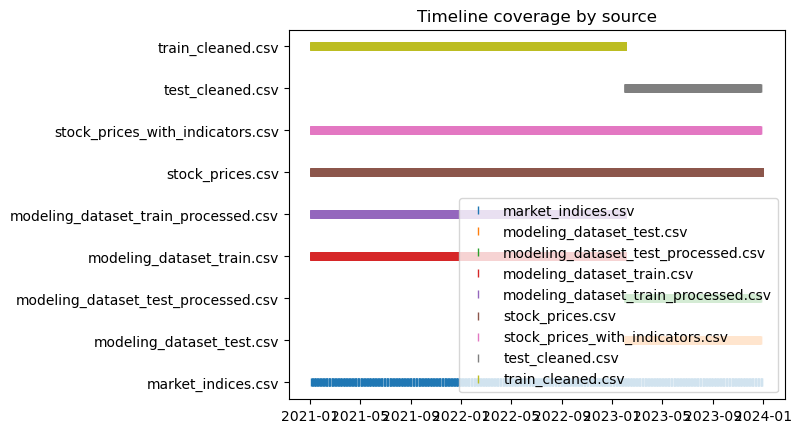

In [28]:
import matplotlib.pyplot as plt

for src, group in Combined_df.groupby('source'):
    plt.plot(group['date'], [src]*len(group), '|', label=src)

plt.legend()
plt.title('Timeline coverage by source')
plt.show()

#### Missing date summary report

In [29]:
missing_dates_summary = {}

for src, group in Combined_df.groupby('source'):
    # Sort and get expected full range
    full_range = pd.date_range(group['date'].min(), group['date'].max(), freq='D')
    missing = full_range.difference(group['date'])
    missing_dates_summary[src] = missing

# Print summary
for src, missing in missing_dates_summary.items():
    print(f"{src}: {len(missing)} missing dates")
    if len(missing) > 0:
        print(missing[:10])  # show first 10 missing dates

market_indices.csv: 310 missing dates
DatetimeIndex(['2021-01-09', '2021-01-10', '2021-01-16', '2021-01-17',
               '2021-01-23', '2021-01-24', '2021-01-30', '2021-01-31',
               '2021-02-06', '2021-02-07'],
              dtype='datetime64[ns]', freq=None)
modeling_dataset_test.csv: 94 missing dates
DatetimeIndex(['2023-02-04', '2023-02-05', '2023-02-11', '2023-02-12',
               '2023-02-18', '2023-02-19', '2023-02-25', '2023-02-26',
               '2023-03-04', '2023-03-05'],
              dtype='datetime64[ns]', freq=None)
modeling_dataset_test_processed.csv: 94 missing dates
DatetimeIndex(['2023-02-04', '2023-02-05', '2023-02-11', '2023-02-12',
               '2023-02-18', '2023-02-19', '2023-02-25', '2023-02-26',
               '2023-03-04', '2023-03-05'],
              dtype='datetime64[ns]', freq=None)
modeling_dataset_train.csv: 216 missing dates
DatetimeIndex(['2021-01-09', '2021-01-10', '2021-01-16', '2021-01-17',
               '2021-01-23', '2021-01-24',

#### Missing value percentage per column in each source data

In [30]:

missing_by_source = (
    Combined_df
    .groupby("source")
    .apply(lambda x: x.isnull().mean() * 100)
    .round(2)
    .reset_index(drop=True)
)
missing_by_source = missing_by_source.melt(
    id_vars="source",
    var_name="Column",
    value_name="Missing_Percentage"
)

print(missing_by_source)

     source       Column  Missing_Percentage
0       0.0       ticker               100.0
1       0.0       ticker                 0.0
2       0.0       ticker               100.0
3       0.0       ticker                 0.0
4       0.0       ticker               100.0
..      ...          ...                 ...
355     0.0  trend_label                 0.0
356     0.0  trend_label               100.0
357     0.0  trend_label                 0.0
358     0.0  trend_label                 0.0
359     0.0  trend_label                 0.0

[360 rows x 3 columns]


C:\Users\ephra\AppData\Local\Temp\ipykernel_35036\3553717373.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean() * 100)


### Data Quality Observations